# 📦 Newsvendor Game — Module 2: Case Studies & Risk Analysis

**This is a take-home module.** Work through all four cases below, generate the
charts in each section, and prepare a short in-class presentation (see the
**Deliverables & Presentation Guide** at the end for exactly what's expected).

## How this builds on Module 1

In Module 1 you played two abstract scenarios with a 5-point discrete demand
distribution and estimated μ and σ from what you observed. Here, you'll apply
the same critical-ratio logic to **more realistic, harder problems**:

| Case | New wrinkle |
|---|---|
| 1. The Downtown Boutique | Continuous, bell-shaped (normal) demand — a real product, real margins |
| 2. Riverside Bakery | **Perishable inventory**: unsold stock partially carries over (with spoilage + holding cost) instead of disappearing each round |
| 3. Farmers Market Stand | **Two products, one shared budget** — you must allocate, not just order |
| 4. Framing Experiment | Same numbers as Case 1, but the *way the decision is framed* changes — testing your own behavioral bias |

Every case ends with three analysis charts you'll use in your write-up and
presentation:

- **Sensitivity ("tornado") chart** — how much does Q\* move if price, cost, or
  salvage value were off by ±20%?
- **Risk-vs-return (efficient frontier) chart** — expected profit vs. profit
  variability across different order quantities
- **Profit distribution (box plot)** — how spread out your outcomes are under
  a few candidate strategies, simulated over many demand draws

---


In [1]:
# ============================================================
# SHARED LIBRARY — used by every case below. Run this cell first.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display, HTML, clear_output
from statistics import NormalDist
from dataclasses import dataclass, asdict
from typing import Optional, List
import os, datetime

try:
    from google.colab import files
    ON_COLAB = True
except Exception:
    ON_COLAB = False

SESSION_LOG = {}  # tag -> list of round dicts, kept around for cross-case comparisons (used in Case 4)

# ---------------- Core engine: one product, normally-distributed demand ----------------

class NewsvendorEngine:
    def __init__(self, p, c, h, mu, sigma, name="Product", rng=None):
        self.p, self.c, self.h = p, c, h
        self.mu, self.sigma = mu, sigma
        self.name = name
        self.rng = rng or np.random.default_rng()

    def sample_demand(self, n=1):
        draws = np.clip(self.rng.normal(self.mu, self.sigma, size=n), 0, None)
        return draws[0] if n == 1 else draws

    def critical_ratio(self):
        Cu, Co = self.p - self.c, self.c - self.h
        return Cu / (Cu + Co) if (Cu + Co) > 0 else 0.0

    def q_star(self):
        cr = min(max(self.critical_ratio(), 1e-6), 1 - 1e-6)
        z = NormalDist().inv_cdf(cr)
        return max(0.0, self.mu + z * self.sigma)

    def profit(self, q, x):
        shortage, surplus = max(x - q, 0), max(q - x, 0)
        shortage_loss = (self.p - self.c) * shortage
        salvage_loss = (self.c - self.h) * surplus
        profit = (self.p * x - self.c * q + self.h * (q - x)) if x < q else (self.p - self.c) * q
        return profit, shortage_loss, salvage_loss

    def simulate_policy(self, q, n=3000):
        xs = self.sample_demand(n)
        return np.array([self.profit(q, x)[0] for x in xs])


# ---------------- Shared chart functions (tornado / frontier / distribution) ----------------

def tornado_chart(engine, pct=0.2, title=None):
    """Sensitivity of Q* to ±pct changes in price, cost, and salvage value, one at a time."""
    base = dict(p=engine.p, c=engine.c, h=engine.h)
    rows = []
    for param, label in [("p", "Price"), ("c", "Cost"), ("h", "Salvage")]:
        lo = NewsvendorEngine(**{**base, param: base[param] * (1 - pct)}, mu=engine.mu, sigma=engine.sigma).q_star()
        hi = NewsvendorEngine(**{**base, param: base[param] * (1 + pct)}, mu=engine.mu, sigma=engine.sigma).q_star()
        rows.append((label, min(lo, hi), max(lo, hi)))
    rows.sort(key=lambda r: r[2] - r[1], reverse=True)
    base_q = engine.q_star()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    for i, (label, lo, hi) in enumerate(rows):
        ax.barh(i, hi - lo, left=lo, color="#4C72B0", alpha=0.85)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([f"{label} (±{int(pct*100)}%)" for label, _, _ in rows])
    ax.axvline(base_q, color="#DD8452", linestyle="--", label=f"Base Q* ≈ {base_q:.0f}")
    ax.set_xlabel("Resulting Q*")
    ax.set_title(title or f"{engine.name}: Sensitivity of Q* to Assumptions")
    ax.legend()
    plt.tight_layout()
    plt.show()

def efficient_frontier_chart(engine, q_range, n_sim=3000, title=None):
    """Expected profit (return) vs. SD of profit (risk) across a range of order quantities."""
    means, stds = [], []
    for q in q_range:
        profits = engine.simulate_policy(q, n_sim)
        means.append(profits.mean())
        stds.append(profits.std(ddof=1))
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot(stds, means, marker='o', color="#55A868")
    for q, x_, y_ in zip(q_range, stds, means):
        ax.annotate(str(int(q)), (x_, y_), textcoords="offset points", xytext=(5, 5), fontsize=8)
    qstar = engine.q_star()
    qstar_profits = engine.simulate_policy(qstar, n_sim)
    ax.scatter([qstar_profits.std(ddof=1)], [qstar_profits.mean()], color="#C44E52", s=100, zorder=5,
               label=f"Q* ≈ {qstar:.0f}")
    ax.set_xlabel("Risk (SD of profit)")
    ax.set_ylabel("Expected profit")
    ax.set_title(title or f"{engine.name}: Risk vs. Return by Order Quantity")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def profit_distribution_chart(engine, strategies, n_sim=3000, title=None):
    """Box plot comparing simulated profit outcomes across named strategies (name -> order quantity)."""
    data, labels = [], []
    for name, q in strategies.items():
        data.append(engine.simulate_policy(q, n_sim))
        labels.append(f"{name}\n(q={q:.0f})")
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.boxplot(data, labels=labels, showmeans=True)
    ax.set_ylabel("Simulated profit")
    ax.set_title(title or f"{engine.name}: Profit Distribution by Strategy")
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print("Shared library loaded.")


Shared library loaded.


## 🥾 Case 1 — The Downtown Boutique: Limited-Edition Sneaker Drop

You manage inventory for a boutique streetwear shop. A limited-edition sneaker
drops **once**, with no restock. Demand is roughly bell-shaped rather than a
handful of equally-likely outcomes — you won't be told μ or σ, only that
demand is "roughly normal." Estimate it from what you observe, the same way
you did in Module 1.

- **Selling price:** \$180 &nbsp;|&nbsp; **Cost:** \$95 &nbsp;|&nbsp;
  **Salvage (outlet resale):** \$40
- Order quantity can be any value (not just multiples of 25) — use the
  slider/box in steps of 5.

**What to do:**
1. Play 15 rounds. Watch the running mean/SD build up.
2. Run the three analysis charts below using your own estimated Q\* and your
   own average order.
3. Record: your average order, μ̂, σ̂, critical ratio, your estimated Q\*, and δq.


In [2]:
# ============================================================
# Generic single-product session runner (used by Cases 1, 2, and 4).
# Supports optional carryover/spoilage/holding cost for perishable cases,
# and optional "frame_text" banner for the behavioral framing experiment.
# ============================================================
@dataclass
class SPRoundResult:
    round_num: int
    order_q: float
    carryover_in: float
    demand_x: float
    sold: float
    leftover: float
    carryover_out: float
    profit: float
    cum_profit: float
    running_mean: float
    running_sd: Optional[float]

def build_single_product_widget(engine, rounds=15, order_min=0, order_max=None, order_step=10,
                                 carryover=False, spoilage_rate=0.0, holding_cost=0.0,
                                 frame_text=None, session_tag="case", title="Newsvendor Session"):
    order_max = order_max or (engine.mu + 4 * engine.sigma)
    STATE = {"results": [], "cum_profit": 0.0, "current_round": 1, "game_over": False, "carryover_stock": 0.0}

    order_in = w.BoundedFloatText(value=round(engine.mu), min=order_min, max=order_max, step=order_step,
                                   description="Order-up-to (S):" if carryover else "Order q:")
    start_btn = w.Button(description="Start / Reset", button_style="primary")
    submit_btn = w.Button(description="Submit", disabled=True)
    download_btn = w.Button(description="Download CSV", disabled=True)
    metrics_out, msg_out = w.Output(), w.Output()
    hist_table_out, hist_chart_out = w.Output(), w.Output()
    summary_out, results_out = w.Output(), w.Output()

    def render_metrics():
        metrics_out.clear_output()
        with metrics_out:
            print(f"Round {min(STATE['current_round'], rounds)} / {rounds}   |   Cumulative profit: {STATE['cum_profit']:.2f}")
            if carryover:
                print(f"Stock carried in from previous round: {STATE['carryover_stock']:.1f}")

    def render_history():
        hist_table_out.clear_output(); hist_chart_out.clear_output()
        res = STATE["results"]
        with hist_table_out:
            if not res:
                print("No rounds played yet."); return
            df = pd.DataFrame({
                "Round": [r.round_num for r in res],
                "Demand": [round(r.demand_x, 1) for r in res],
                "Running Mean": [round(r.running_mean, 2) for r in res],
                "Running SD": [round(r.running_sd, 2) if r.running_sd is not None else None for r in res],
            })
            display(df)
            last = res[-1]
            sd_txt = f"{last.running_sd:.2f}" if last.running_sd is not None else "N/A"
            print(f"μ̂ = {last.running_mean:.2f}  |  σ̂ = {sd_txt}")
        if not res:
            return
        with hist_chart_out:
            fig, ax = plt.subplots(figsize=(7, 3.2))
            ax.plot([r.round_num for r in res], [r.demand_x for r in res], marker='o', label="Demand")
            ax.plot([r.round_num for r in res], [r.running_mean for r in res], linestyle='--', label="Running mean")
            ax.set_xlabel("Round"); ax.set_ylabel("Demand"); ax.legend(); ax.grid(alpha=0.3)
            plt.tight_layout(); plt.show()

    def reset(_=None):
        STATE.update({"results": [], "cum_profit": 0.0, "current_round": 1, "game_over": False, "carryover_stock": 0.0})
        order_in.disabled = False; submit_btn.disabled = False; download_btn.disabled = True
        for o in [msg_out, summary_out, results_out]:
            o.clear_output()
        render_metrics(); render_history()
        with msg_out:
            display(HTML(f"<b>{title}</b> started. Enter your decision and click Submit."))

    def submit(_=None):
        if STATE["game_over"]:
            return
        S_or_q = order_in.value
        carry_in = STATE["carryover_stock"] if carryover else 0.0
        order_placed = max(S_or_q - carry_in, 0.0) if carryover else S_or_q
        available = (carry_in + order_placed) if carryover else S_or_q
        x = float(engine.sample_demand(1))
        sold = min(available, x)
        leftover = available - sold
        carry_out = leftover * (1 - spoilage_rate) if carryover else 0.0
        revenue = engine.p * sold
        purchase_cost = engine.c * order_placed
        hold_cost = holding_cost * carry_out if carryover else 0.0
        profit = revenue - purchase_cost - hold_cost
        STATE["cum_profit"] += profit
        prior = [r.demand_x for r in STATE["results"]]
        all_d = prior + [x]
        running_mean = float(np.mean(all_d))
        running_sd = float(np.std(all_d, ddof=1)) if len(all_d) > 1 else None
        rr = SPRoundResult(STATE["current_round"], S_or_q, carry_in, x, sold, leftover, carry_out,
                            profit, STATE["cum_profit"], running_mean, running_sd)
        STATE["results"].append(rr)
        STATE["carryover_stock"] = carry_out
        STATE["current_round"] += 1
        if STATE["current_round"] > rounds:
            STATE["game_over"] = True
        render_metrics(); render_history()
        with msg_out:
            clear_output()
            extra = f" | Carried to next round: {carry_out:.1f}" if carryover else ""
            display(HTML(f"Order: <b>{S_or_q:.0f}</b> | Demand: <b>{x:.1f}</b> | Sold: <b>{sold:.1f}</b> | "
                          f"Profit: <b>{profit:.2f}</b>{extra}"))
        if STATE["game_over"]:
            with summary_out:
                clear_output()
                orders = [r.order_q for r in STATE["results"]]
                print(f"Average order: {np.mean(orders):.2f}")
                print(f"Estimated mu-hat: {STATE['results'][-1].running_mean:.2f}, sigma-hat: {STATE['results'][-1].running_sd:.2f}")
                print(f"Critical ratio CR: {engine.critical_ratio():.3f}")
                print(f"Total profit: {STATE['cum_profit']:.2f}")
            with results_out:
                display(pd.DataFrame([asdict(r) for r in STATE["results"]]))
            SESSION_LOG[session_tag] = [asdict(r) for r in STATE["results"]]
            download_btn.disabled = False
            order_in.disabled = True; submit_btn.disabled = True

    def download(_=None):
        if not STATE["results"]:
            return
        df = pd.DataFrame([asdict(r) for r in STATE["results"]])
        fname = f"newsvendor_{session_tag}_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}.csv"
        path = os.path.join("/content" if ON_COLAB else ".", fname)
        df.to_csv(path, index=False)
        if ON_COLAB:
            files.download(path)
        else:
            print(f"Saved to {path}")

    start_btn.on_click(reset); submit_btn.on_click(submit); download_btn.on_click(download)

    header = w.HTML(f"<h3>{title}</h3>")
    frame_html = w.HTML(f"<div style='background:#f6f6f6;padding:10px;border-radius:6px;'>{frame_text}</div>") if frame_text else w.HTML("")
    box = w.VBox([header, frame_html, w.HBox([order_in]), w.HBox([start_btn, submit_btn, download_btn]),
                  metrics_out, msg_out, hist_table_out, hist_chart_out, summary_out,
                  w.HTML("<h4>Round-by-round results</h4>"), results_out])
    return box, STATE


In [4]:
# Case 1 setup + play
case1_engine = NewsvendorEngine(p=180, c=95, h=40, mu=300, sigma=60, name="Sneaker Drop")

box1, STATE1 = build_single_product_widget(
    case1_engine, rounds=15, order_min=0, order_max=500, order_step=5,
    session_tag="case1", title="Case 1: The Downtown Boutique"
)
display(box1)


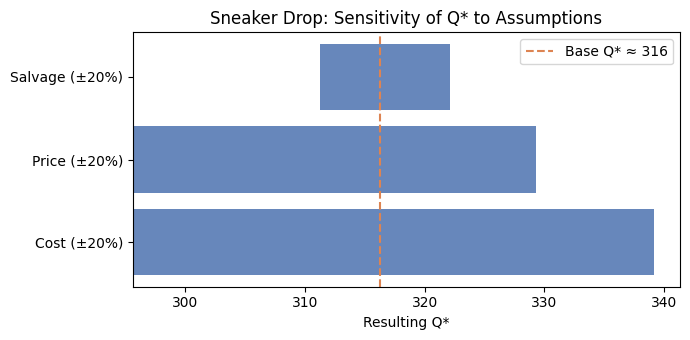

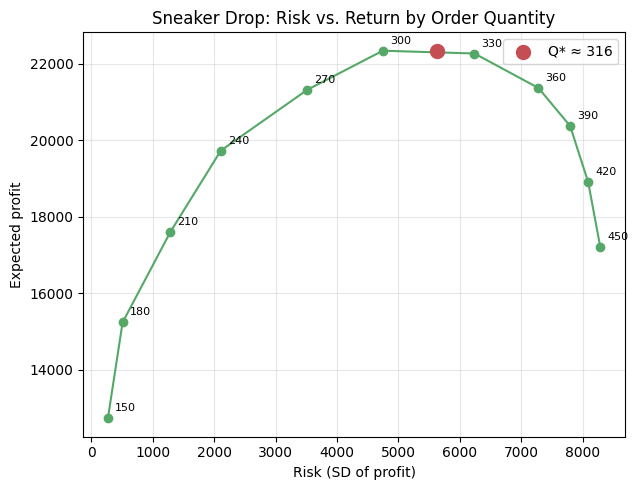

/tmp/ipykernel_3267/3446773278.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


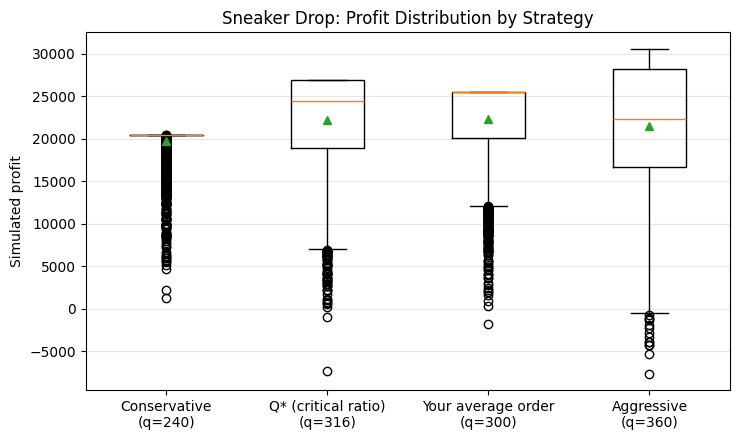

In [5]:
# Case 1 — analysis charts. Run this AFTER playing all 15 rounds above.
avg_order_1 = np.mean([r["order_q"] for r in SESSION_LOG.get("case1", [])]) if "case1" in SESSION_LOG else case1_engine.mu

tornado_chart(case1_engine, pct=0.2)
efficient_frontier_chart(case1_engine, q_range=range(150, 451, 30))
profit_distribution_chart(case1_engine, strategies={
    "Conservative": case1_engine.mu - case1_engine.sigma,
    "Q* (critical ratio)": case1_engine.q_star(),
    "Your average order": avg_order_1,
    "Aggressive": case1_engine.mu + case1_engine.sigma,
})


## 🥖 Case 2 — Riverside Bakery: Sourdough Boules (Perishable Inventory)

Unlike Case 1, unsold loaves **don't disappear overnight** — day-old bread
stays edible but degrades. Each night:

- **35% of leftover loaves go stale and are discarded** (spoilage).
- The remaining **65% carry over** to tomorrow, but cost you a small
  **holding/refrigeration fee** for every loaf carried.
- You don't order a fixed quantity each day — you choose an **order-up-to
  level S**: "bring total available stock up to S loaves." If you already
  have leftover stock, you only bake/order the difference.

- **Selling price:** \$7.50 &nbsp;|&nbsp; **Cost to bake:** \$2.75 &nbsp;|&nbsp;
  **Holding cost:** \$0.50/loaf/night &nbsp;|&nbsp; **Spoilage rate:** 35%/night

**What to do:**
1. Play 15 rounds. Notice how carryover changes your optimal strategy — you
   may want to order-up-to a lower S than in Case 1, since leftover stock is
   no longer a total loss.
2. Run the three charts (note: they treat the *no-carryover* single-period
   version of this product for comparison — discuss in your write-up whether
   you'd expect your actual carryover strategy to beat that baseline).
3. Record: your average S, observed demand μ̂/σ̂, and a 2-3 sentence
   explanation of how spoilage + holding cost changed your ordering logic
   versus Case 1.


In [7]:
# Case 2 setup + play (carryover enabled)
case2_engine = NewsvendorEngine(p=7.50, c=2.75, h=0, mu=40, sigma=10, name="Sourdough Boules")

box2, STATE2 = build_single_product_widget(
    case2_engine, rounds=15, order_min=0, order_max=100, order_step=2,
    carryover=True, spoilage_rate=0.35, holding_cost=0.50,
    session_tag="case2", title="Case 2: Riverside Bakery (order-up-to level S)"
)
display(box2)


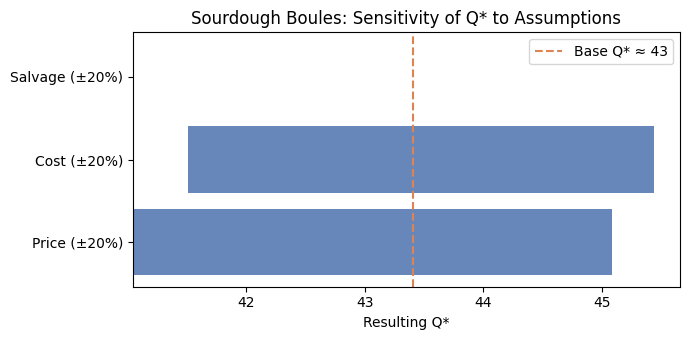

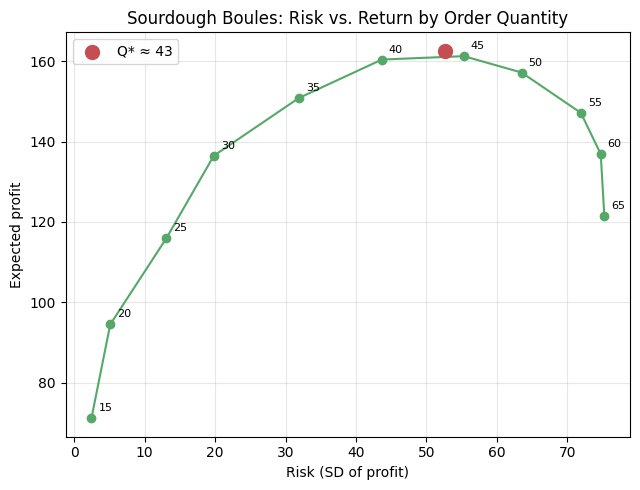

/tmp/ipykernel_3267/3446773278.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


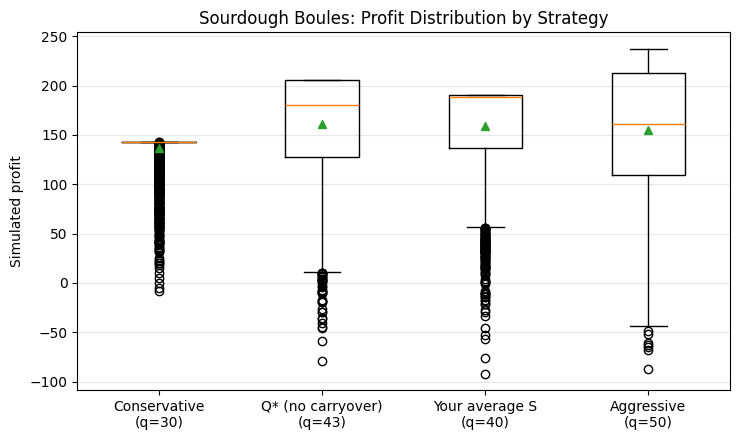

In [8]:
# Case 2 — analysis charts (single-period baseline, for comparison to your carryover strategy)
avg_S_2 = np.mean([r["order_q"] for r in SESSION_LOG.get("case2", [])]) if "case2" in SESSION_LOG else case2_engine.mu

tornado_chart(case2_engine, pct=0.2)
efficient_frontier_chart(case2_engine, q_range=range(15, 66, 5))
profit_distribution_chart(case2_engine, strategies={
    "Conservative": case2_engine.mu - case2_engine.sigma,
    "Q* (no carryover)": case2_engine.q_star(),
    "Your average S": avg_S_2,
    "Aggressive": case2_engine.mu + case2_engine.sigma,
})


## 🍅 Case 3 — Farmers Market Stand: Budget-Constrained Allocation

You run a market stall selling **two products** and must decide how much of
each to bring, but you have a **fixed daily cash budget** for buying stock —
you can't just order the individually-optimal Q\* for both.

| Product | Price | Cost | Demand μ | Demand σ |
|---|---|---|---|---|
| Heirloom tomatoes | \$6.00/lb | \$2.50/lb | 120 lb | 25 lb |
| Fresh basil | \$3.00/bunch | \$0.80/bunch | 80 bunches | 20 bunches |

**Daily budget: \$400**

**What to do:**
1. Each round, enter an order quantity for both products. The budget check
   below turns red if your total cost exceeds \$400 — adjust before
   submitting.
2. Play 15 rounds. Use the **decision aid** table (critical ratio and
   *unconstrained* Q\* per product — ignoring the budget) to reason about
   which product deserves more of your limited cash. This is a hint, not
   the answer: the *unconstrained* optimum for both products together may
   not be affordable.
3. Record: your allocation strategy, total profit, and a short explanation
   of how you split the budget and why.


In [9]:
# ============================================================
# Generic two-(or more)-product, shared-budget session runner (Case 3).
# ============================================================
def build_multi_product_widget(engines: List[NewsvendorEngine], budget, rounds=15, title="Multi-Product Allocation"):
    STATE = {"results": [], "cum_profit": 0.0, "current_round": 1, "game_over": False}
    order_ins = [w.BoundedFloatText(value=round(e.mu * 0.5), min=0, max=e.mu + 4 * e.sigma, step=5,
                                     description=f"{e.name} q:") for e in engines]
    budget_out, hint_out = w.Output(), w.Output()
    start_btn = w.Button(description="Start / Reset", button_style="primary")
    submit_btn = w.Button(description="Submit", disabled=True)
    download_btn = w.Button(description="Download CSV", disabled=True)
    msg_out, results_out, summary_out = w.Output(), w.Output(), w.Output()

    def render_budget_check():
        budget_out.clear_output()
        with budget_out:
            spend = sum(e.c * o.value for e, o in zip(engines, order_ins))
            over = spend > budget
            color = "red" if over else "green"
            display(HTML(f"<span style='color:{color};'>Planned spend: {spend:.2f} / Budget: {budget:.2f}"
                          f"{' &nbsp;⚠️ OVER BUDGET' if over else ''}</span>"))

    for o in order_ins:
        o.observe(lambda change: render_budget_check(), names="value")

    def render_hint():
        hint_out.clear_output()
        with hint_out:
            rows = [{"Product": e.name, "Price": e.p, "Cost": e.c,
                     "Critical Ratio": round(e.critical_ratio(), 3),
                     "Unconstrained Q* (ignoring budget)": round(e.q_star(), 1)} for e in engines]
            display(HTML("<b>Decision aid (unconstrained per-product Q* — your budget may not allow all of it):</b>"))
            display(pd.DataFrame(rows))

    def reset(_=None):
        STATE.update({"results": [], "cum_profit": 0.0, "current_round": 1, "game_over": False})
        for o in order_ins:
            o.disabled = False
        submit_btn.disabled = False; download_btn.disabled = True
        for out in [msg_out, summary_out, results_out]:
            out.clear_output()
        render_budget_check(); render_hint()
        with msg_out:
            display(HTML(f"<b>{title}</b> started."))

    def submit(_=None):
        if STATE["game_over"]:
            return
        qs = [o.value for o in order_ins]
        spend = sum(e.c * q for e, q in zip(engines, qs))
        if spend > budget:
            with msg_out:
                clear_output()
                display(HTML(f"<span style='color:red;'>Total cost {spend:.2f} exceeds budget {budget:.2f}. Adjust and resubmit.</span>"))
            return
        xs = [float(e.sample_demand(1)) for e in engines]
        round_profit = 0.0
        breakdown = []
        for e, q, x in zip(engines, qs, xs):
            prof, _, _ = e.profit(q, x)
            round_profit += prof
            breakdown.append((e.name, q, x, prof))
        STATE["cum_profit"] += round_profit
        STATE["results"].append({"round": STATE["current_round"], "profit": round_profit,
                                  "cum_profit": STATE["cum_profit"], "breakdown": breakdown})
        STATE["current_round"] += 1
        if STATE["current_round"] > rounds:
            STATE["game_over"] = True
        with msg_out:
            clear_output()
            lines = "<br>".join([f"{n}: q={q:.0f}, demand={x:.1f}, profit={p:.2f}" for n, q, x, p in breakdown])
            display(HTML(f"Round profit: <b>{round_profit:.2f}</b><br>{lines}"))
        render_budget_check()
        if STATE["game_over"]:
            with summary_out:
                print(f"Total profit over {rounds} rounds: {STATE['cum_profit']:.2f}")
            rows = []
            for r in STATE["results"]:
                row = {"Round": r["round"], "Profit": r["profit"], "Cum_Profit": r["cum_profit"]}
                for (n, q, x, p) in r["breakdown"]:
                    row[f"{n}_q"] = q; row[f"{n}_demand"] = x; row[f"{n}_profit"] = p
                rows.append(row)
            with results_out:
                display(pd.DataFrame(rows))
            for o in order_ins:
                o.disabled = True
            submit_btn.disabled = True; download_btn.disabled = False

    def download(_=None):
        if not STATE["results"]:
            return
        rows = []
        for r in STATE["results"]:
            row = {"Round": r["round"], "Profit": r["profit"], "Cum_Profit": r["cum_profit"]}
            for (n, q, x, p) in r["breakdown"]:
                row[f"{n}_q"] = q; row[f"{n}_demand"] = x; row[f"{n}_profit"] = p
            rows.append(row)
        df = pd.DataFrame(rows)
        fname = f"newsvendor_multiproduct_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}.csv"
        path = os.path.join("/content" if ON_COLAB else ".", fname)
        df.to_csv(path, index=False)
        if ON_COLAB:
            files.download(path)
        else:
            print(f"Saved to {path}")

    start_btn.on_click(reset); submit_btn.on_click(submit); download_btn.on_click(download)
    box = w.VBox([w.HTML(f"<h3>{title}</h3>"), w.HTML(f"<p>Daily budget: <b>{budget}</b></p>"),
                  *[w.HBox([o]) for o in order_ins], budget_out,
                  w.HBox([start_btn, submit_btn, download_btn]), msg_out, hint_out, summary_out,
                  w.HTML("<h4>Round-by-round results</h4>"), results_out])
    return box, STATE


In [10]:
# Case 3 setup + play
tomatoes = NewsvendorEngine(p=6.00, c=2.50, h=0, mu=120, sigma=25, name="Tomatoes")
basil = NewsvendorEngine(p=3.00, c=0.80, h=0, mu=80, sigma=20, name="Basil")

box3, STATE3 = build_multi_product_widget([tomatoes, basil], budget=400, rounds=15,
                                           title="Case 3: Farmers Market Stand")
display(box3)


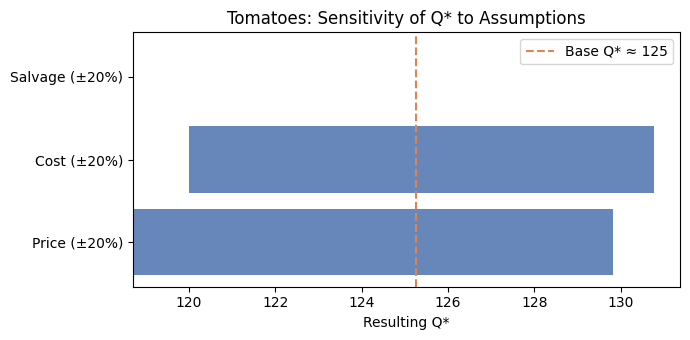

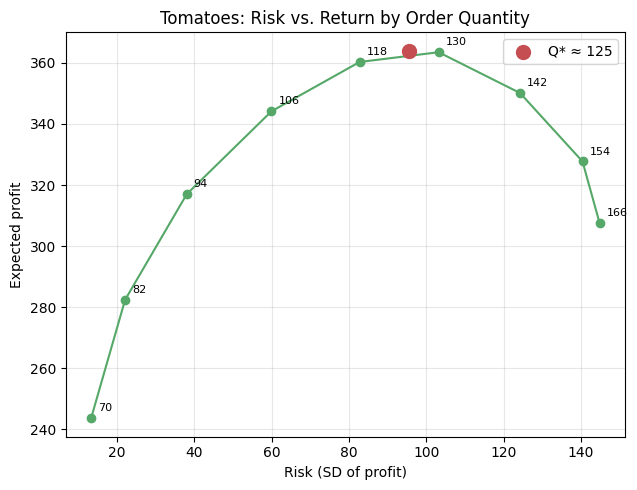

/tmp/ipykernel_657/3446773278.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


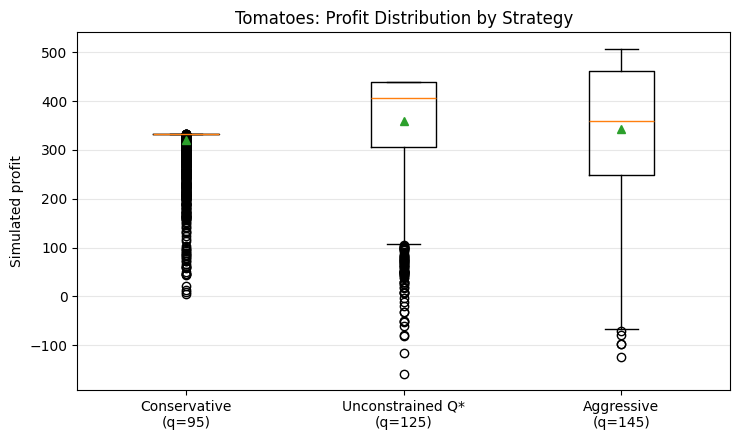

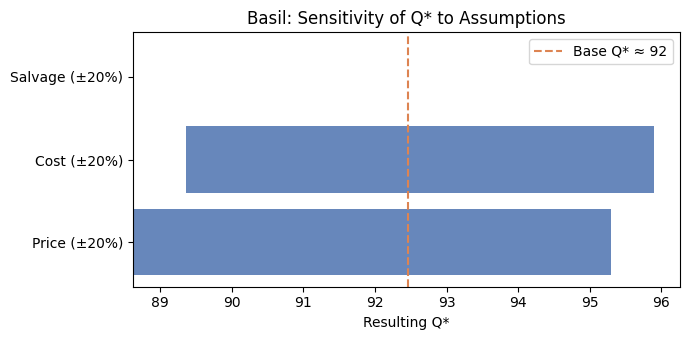

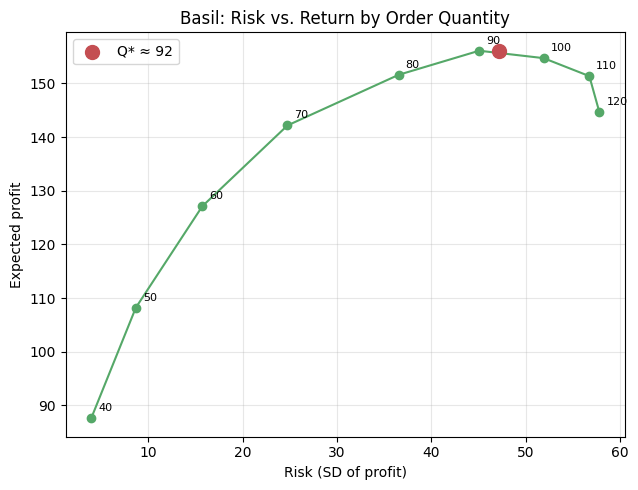

/tmp/ipykernel_657/3446773278.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


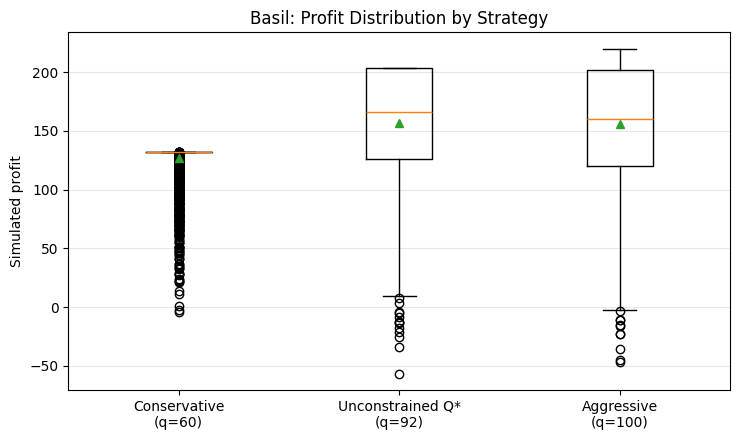

In [ ]:
# Case 3 — per-product analysis charts (each product's own risk/sensitivity in isolation)
for e in [tomatoes, basil]:
    tornado_chart(e, pct=0.2)
    efficient_frontier_chart(e, q_range=range(int(e.mu - 2*e.sigma), int(e.mu + 2*e.sigma) + 1, int(e.sigma/2)))
    profit_distribution_chart(e, strategies={
        "Conservative": e.mu - e.sigma,
        "Unconstrained Q*": e.q_star(),
        "Aggressive": e.mu + e.sigma,
    })


## 🧠 Case 4 — Framing Experiment: Does How You're Told Affect What You Order?

Same product, same numbers as **Case 1** (the Boutique sneaker drop) — but
you'll play it twice, under two different framings of the identical decision.
Play **Frame A first, then Frame B**, in separate sittings if you can
(don't let memory of your first answer anchor the second).

- **Frame A (Gain framing):** "Every pair you sell earns you profit. Order
  well and maximize your take-home earnings."
- **Frame B (Loss framing):** "Every pair you fail to sell is money lost to
  markdown. Every customer you turn away is profit lost forever. Avoid
  these losses."

**What to do:**
1. Play both frames (15 rounds each).
2. Run the comparison cell at the end — it reports your average order under
   each frame.
3. In your write-up: did the frame move your average order? Which direction,
   and does it match what Prospect Theory would predict about loss aversion?


In [13]:
# Case 4 setup — same underlying product as Case 1, two different frames
case4_engine = NewsvendorEngine(p=180, c=95, h=40, mu=300, sigma=60, name="Sneaker Drop (Framing Study)")

frame_a_text = ("<b>Frame A — Gain framing:</b> Every pair you sell earns you profit. "
                "Order well and maximize your take-home earnings.")
box4a, STATE4A = build_single_product_widget(
    case4_engine, rounds=15, order_min=0, order_max=500, order_step=5,
    frame_text=frame_a_text, session_tag="case4_gain", title="Case 4A: Gain Frame"
)
display(box4a)


In [14]:
# Case 4B — same numbers, loss framing. Play this AFTER finishing Case 4A above.
frame_b_text = ("<b>Frame B — Loss framing:</b> Every pair you fail to sell is money lost to markdown. "
                "Every customer you turn away is profit lost forever. Avoid these losses.")
box4b, STATE4B = build_single_product_widget(
    case4_engine, rounds=15, order_min=0, order_max=500, order_step=5,
    frame_text=frame_b_text, session_tag="case4_loss", title="Case 4B: Loss Frame"
)
display(box4b)


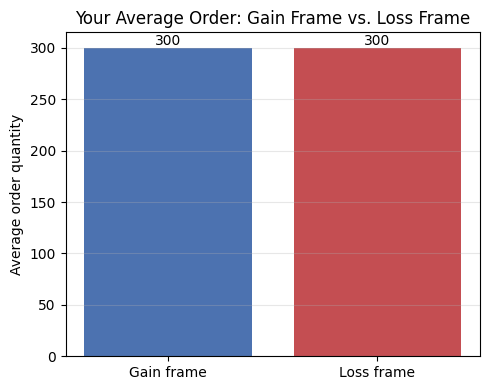

Gain frame average order: 300.0
Loss frame average order: 300.0
Difference (Loss - Gain): +0.0


In [15]:
# Case 4 — compare your average order under each frame (run after playing BOTH 4A and 4B)
if "case4_gain" in SESSION_LOG and "case4_loss" in SESSION_LOG:
    avg_gain = np.mean([r["order_q"] for r in SESSION_LOG["case4_gain"]])
    avg_loss = np.mean([r["order_q"] for r in SESSION_LOG["case4_loss"]])
    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(["Gain frame", "Loss frame"], [avg_gain, avg_loss], color=["#4C72B0", "#C44E52"])
    ax.set_ylabel("Average order quantity")
    ax.set_title("Your Average Order: Gain Frame vs. Loss Frame")
    for b, v in zip(bars, [avg_gain, avg_loss]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.0f}", ha='center', va='bottom')
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    print(f"Gain frame average order: {avg_gain:.1f}")
    print(f"Loss frame average order: {avg_loss:.1f}")
    print(f"Difference (Loss - Gain): {avg_loss - avg_gain:+.1f}")
else:
    print("Play both Case 4A (gain frame) and Case 4B (loss frame) fully before running this cell.")


## ✅ Deliverables & In-Class Presentation Guide

### Required for all students
- **Cases 1 and 2 are mandatory.** For each, submit:
  - Your results CSV (Download CSV button)
  - A short table: average order (or average S for Case 2), μ̂, σ̂, critical
    ratio, your estimated Q\*, and δq
  - Screenshots or copies of your three analysis charts (tornado, frontier,
    distribution)

### Choose ONE of the following to also complete and present
- **Case 3 (multi-product):** your allocation strategy, total profit, and how
  you split the budget between products
- **Case 4 (framing):** your gain-frame vs. loss-frame comparison chart and a
  short interpretation

### In-class presentation (aim for ~8 minutes per group/individual)
1. **1 slide:** Case 1 — your Q\* estimate and how close your average order
   came to it (δq)
2. **1 slide:** Case 2 — how the perishable/carryover mechanic changed your
   strategy relative to Case 1
3. **1 slide:** your chosen elective case (3 or 4) — what you found
4. **1 slide:** pick ONE of your three chart types and explain what it would
   tell a manager who has never seen a newsvendor model before
5. **1 slide:** takeaway — in your own words, what's the single biggest
   difference between "solve it with a formula" and "the way people actually
   behave," based on everything you've seen across Module 1 and Module 2?

### Grading emphasis
We're less interested in whether your Q\* estimate was "correct" (you were
estimating from noisy samples, so some error is expected) and more interested
in whether you can **read and explain the three chart types** — that's the
transferable skill.
